In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [28]:
df = pd.read_csv("Advertising.csv")

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [29]:
print("Shape:", df.shape)
df.info()

Shape: (200, 4)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [30]:
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

print("Shape:", df.shape)

Shape: (200, 4)


In [31]:
print(df.isnull().sum())

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [32]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


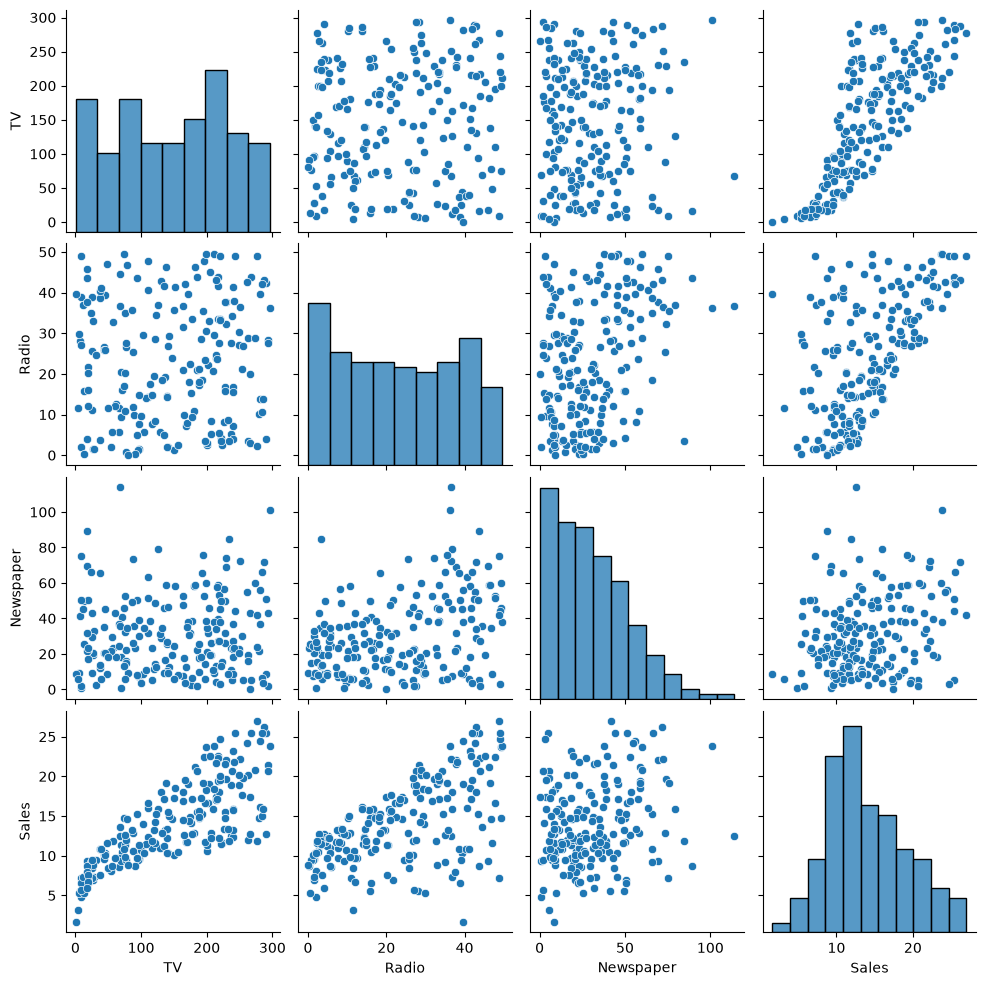

In [33]:
sns.pairplot(df)

plt.show()

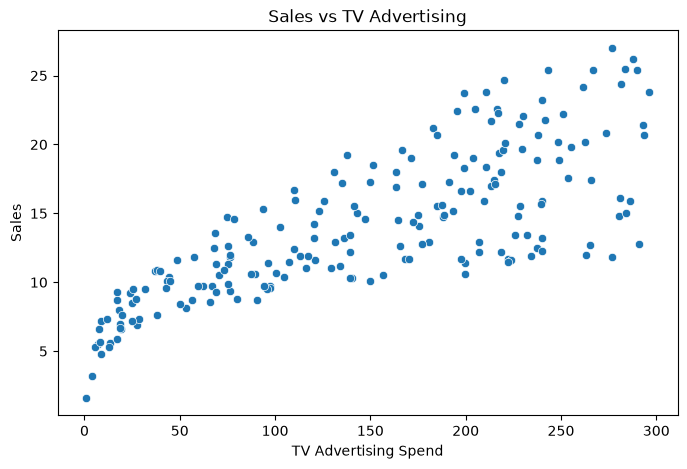

In [34]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="TV", y="Sales")

plt.title("Sales vs TV Advertising")
plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")

plt.show()

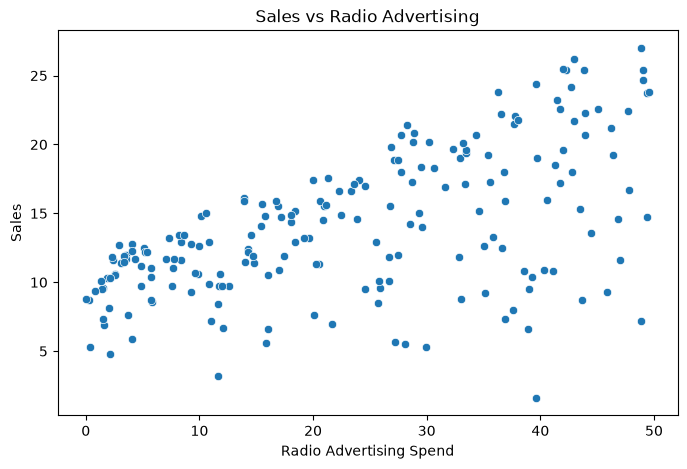

In [35]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Radio", y="Sales")

plt.title("Sales vs Radio Advertising")
plt.xlabel("Radio Advertising Spend")
plt.ylabel("Sales")

plt.show()

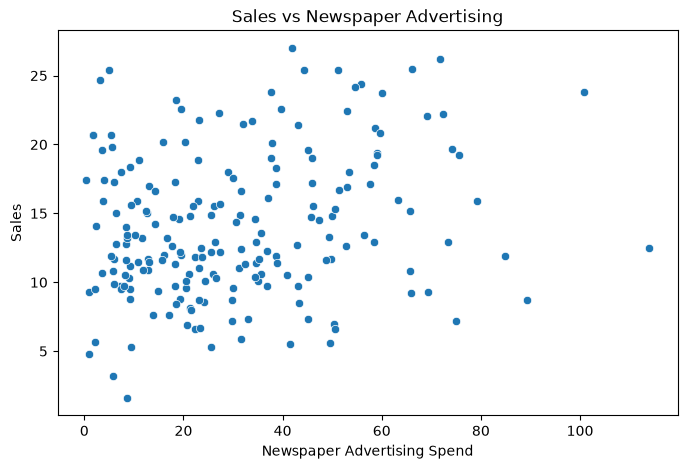

In [36]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Newspaper", y="Sales")

plt.title("Sales vs Newspaper Advertising")
plt.xlabel("Newspaper Advertising Spend")
plt.ylabel("Sales")

plt.show()

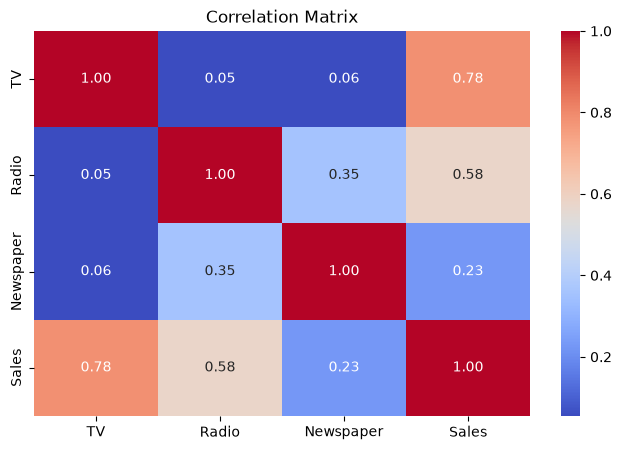

In [37]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [38]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Target:
0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64


In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 3)
Testing data: (40, 3)


In [40]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

print("Linear Regression model trained.")

Linear Regression model trained.


In [41]:
random_forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

rf_predictions = random_forest_model.predict(X_test)

print("Random Forest model trained.")

Random Forest model trained.


In [42]:
def evaluate_model(name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)

    print(name)
    print("MAE:", round(mae, 4))
    print("RMSE:", round(rmse, 4))
    print("R2 Score:", round(r2, 4))
    print("-" * 30)

    return mae, rmse, r2

In [43]:
linear_results = evaluate_model(
    "Linear Regression",
    y_test,
    linear_predictions
)

rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_predictions
)

Linear Regression
MAE: 1.4608
RMSE: 1.7816
R2 Score: 0.8994
------------------------------
Random Forest
MAE: 0.6289
RMSE: 0.7577
R2 Score: 0.9818
------------------------------


In [44]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_results[0],
        rf_results[0]
    ],
    "RMSE": [
        linear_results[1],
        rf_results[1]
    ],
    "R2 Score": [
        linear_results[2],
        rf_results[2]
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.460757,1.781600,0.899438
1,Random Forest,0.628925,0.757657,0.981813


In [45]:
best_model_name = results.loc[
    results["R2 Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Random Forest


In [46]:
if best_model_name == "Linear Regression":
    best_predictions = linear_predictions
else:
    best_predictions = rf_predictions

residuals = y_test - best_predictions

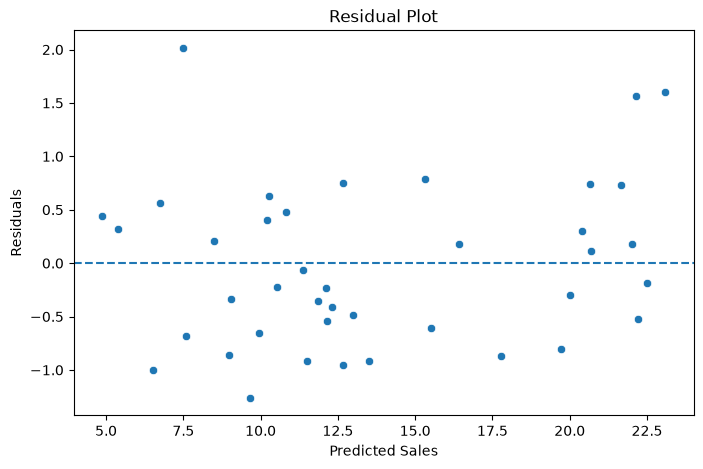

In [47]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=best_predictions,
    y=residuals
)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [48]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient
1,Radio,0.189195
0,TV,0.044730
2,Newspaper,0.002761


In [49]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,TV,0.624729
1,Radio,0.362129
2,Newspaper,0.013142


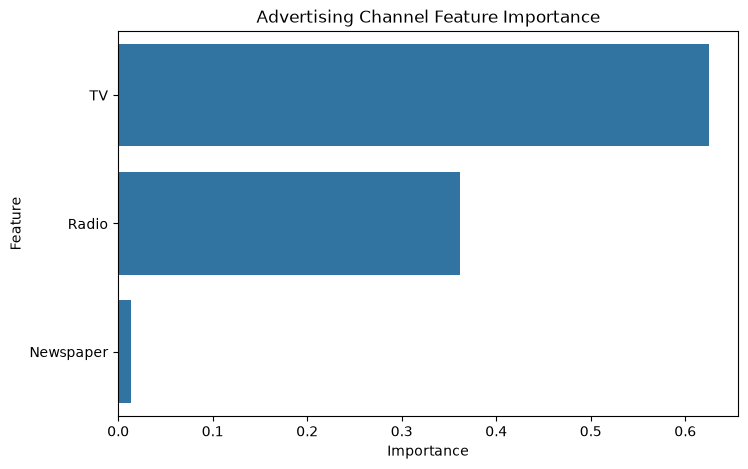

In [50]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Advertising Channel Feature Importance")

plt.show()

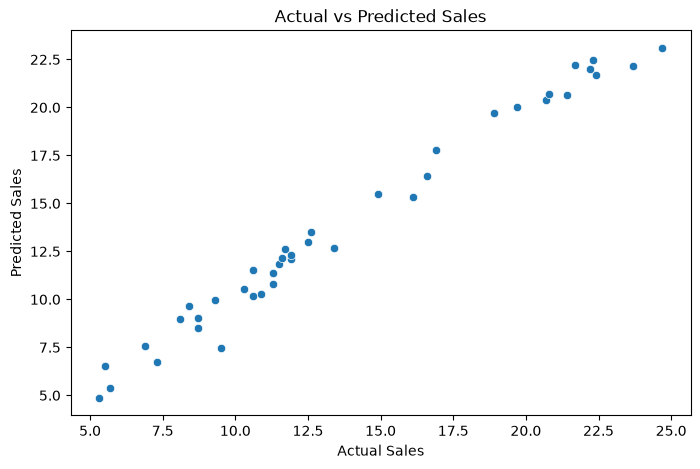

In [51]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_test,
    y=best_predictions
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

In [52]:
if best_model_name == "Linear Regression":
    final_model = linear_model
else:
    final_model = random_forest_model

with open("sales_prediction_model.pkl", "wb") as file:
    pickle.dump(final_model, file)

print("Model saved successfully.")

NameError: name 'pickle' is not defined